In [170]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [171]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/ap4825/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


In [172]:
data = xr.open_dataset(fname)

data

<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [173]:
for var in data.data_vars:
    print(f"{var:<60}: {data[var].attrs.get('long_name')}")

toa_sw_all_mon                                              : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon                                              : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon                                             : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon                                              : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon                                              : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon                                             : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon                                              : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon                                              : Top 

In [174]:
time_mean = data.mean(dim='time')

In [175]:
time_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

Text(0.5, 1.0, 'TOA Outgoing Shortwave')

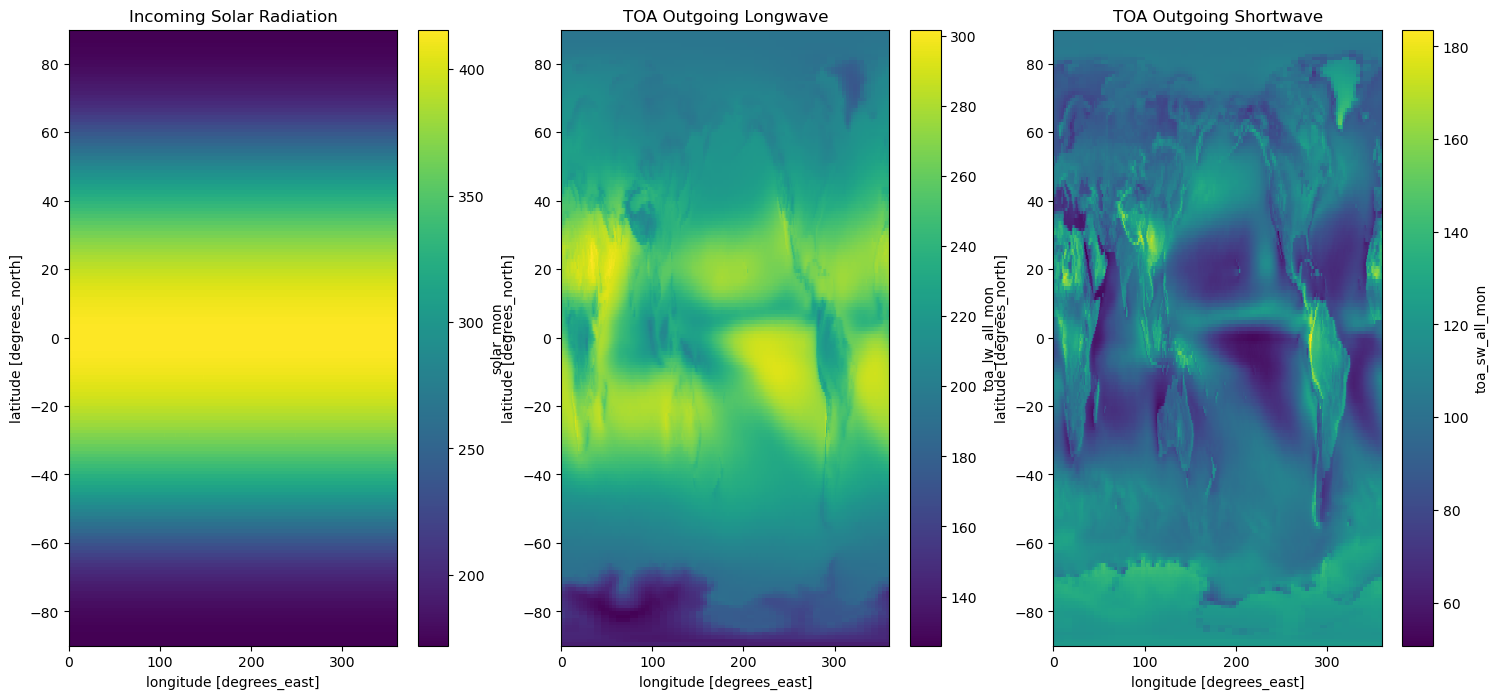

In [176]:
fig, ax = plt.subplots(1, 3, figsize=(18, 8))
time_mean['solar_mon'].plot(ax=ax[0])
ax[0].set_title('Incoming Solar Radiation')

time_mean['toa_lw_all_mon'].plot(ax=ax[1])
ax[1].set_title('TOA Outgoing Longwave')

time_mean['toa_sw_all_mon'].plot(ax=ax[2])
ax[2].set_title('TOA Outgoing Shortwave')

In [177]:
toa_net = time_mean['solar_mon'] - time_mean['toa_lw_all_mon'] - time_mean['toa_sw_all_mon']

Text(0.5, 1.0, 'Actual TOA Net Flux')

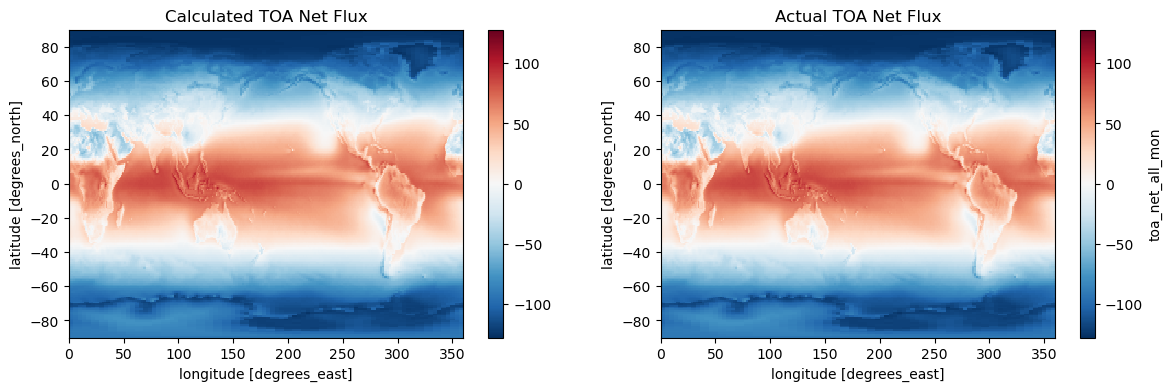

In [178]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

toa_net.plot(ax=ax[0])
ax[0].set_title('Calculated TOA Net Flux')

time_mean['toa_net_all_mon'].plot(ax=ax[1])
ax[1].set_title('Actual TOA Net Flux')

In [179]:
toa_net_mean = time_mean['toa_net_all_mon'].mean()
print(toa_net_mean.values)

-28.729012


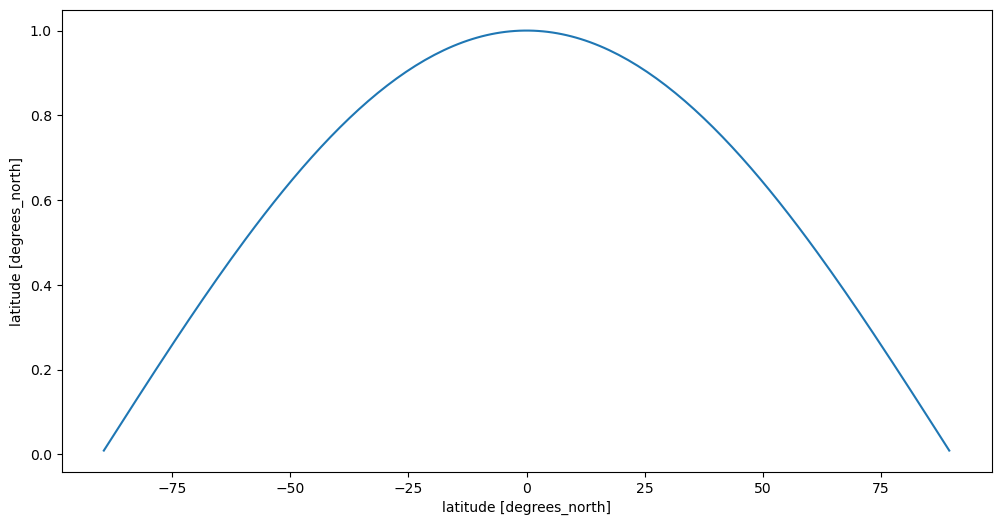

In [180]:
weight_array = np.cos(np.deg2rad(data['lat']))
weight_array.name = 'weights' 
weight_array.plot()

In [181]:
toa_net_weighted = time_mean['toa_net_all_mon'].weighted(weight_array)
weighted_mean = toa_net_weighted.mean(dim=['lat', 'lon'])
print(weighted_mean.values)

0.87808675


I think our calculation is on the right track since it is positive reflecting global warming we are experiencing but our calculation is likely not very precise and ovesimplified. 

In [182]:
solar_weight = time_mean['solar_mon'].weighted(weight_array).mean(dim=['lat', 'lon'])
lw_weight = time_mean['toa_lw_all_mon'].weighted(weight_array).mean(dim=['lat', 'lon'])
sw_weight = time_mean['toa_sw_all_mon'].weighted(weight_array).mean(dim=['lat', 'lon'])

In [183]:
print(f"Incoming Solar {solar_weight.values} W/m²")
print(f"Outgoing Longwave {lw_weight.values} W/m²")
print(f"Outgoing Shortwave {sw_weight.values} W/m²")

Incoming Solar 340.2835388183594 W/m²
Outgoing Longwave 240.26669311523438 W/m²
Outgoing Shortwave 99.13859558105469 W/m²


In [184]:
R = 6371


dlat = np.deg2rad(data['lat'].diff('lat').values[0])
dlon = np.deg2rad(data['lon'].diff('lon').values[0])


pixel_area = R**2 * np.cos(np.deg2rad(data['lat'])) * dlat * dlon * xr.ones_like(time_mean['toa_net_all_mon'])

pixel_area.name = 'pixel_area'
print(f"Sum of all pixel areas: {pixel_area.sum().values} m²")

earth_area = 4 * np.pi * R**2
print(f"Earth's true surface area: {earth_area} m²")

Sum of all pixel areas: 510070941.6521716 m²
Earth's true surface area: 510064471.90978825 m²


Text(0.5, 0, 'Latitude')

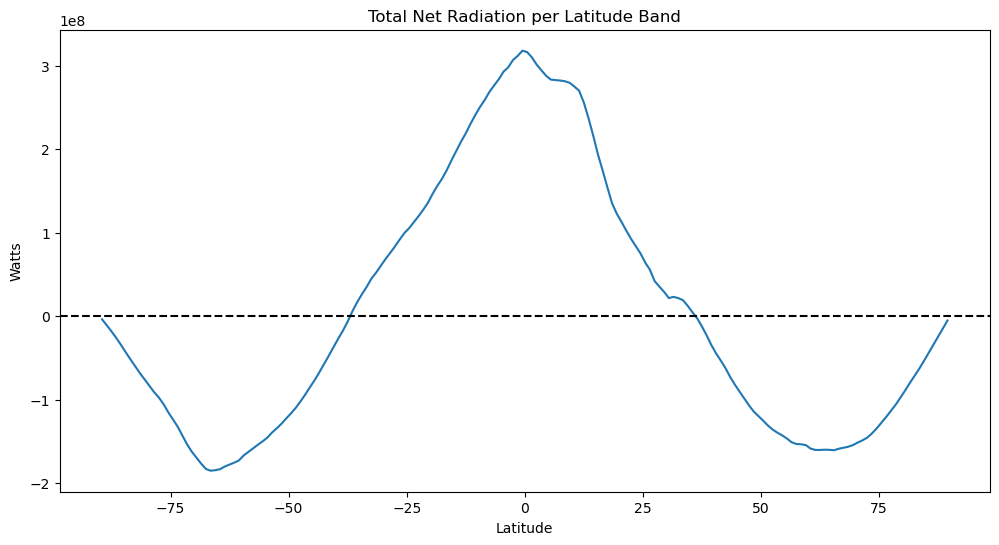

In [185]:
total_rad = pixel_area * time_mean['toa_net_all_mon']


rad_per_lat = total_rad.sum(dim='lon')

rad_per_lat.plot()
plt.axhline(0, color='k', linestyle='--')  
plt.title('Total Net Radiation per Latitude Band')
plt.ylabel('Watts')
plt.xlabel('Latitude')


Text(0.5, 0, 'Latitude')

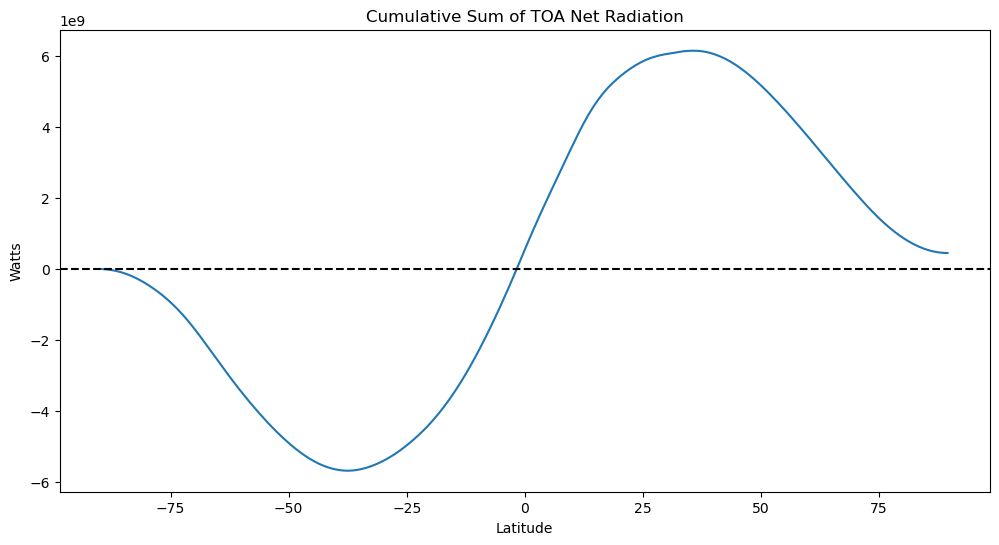

In [186]:
rad_sum = rad_per_lat.cumsum(dim='lat')


rad_sum.plot()
plt.axhline(0, color='k', linestyle='--')  
plt.title('Cumulative Sum of TOA Net Radiation')
plt.ylabel('Watts')
plt.xlabel('Latitude')

In [187]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy as cp

plt.savefig("/tmp/narr_precip_hgt_v3.png", dpi=150, bbox_inches="tight")

hgt_url  = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc"
apcp_url = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc"
 
ds_hgt  = xr.open_dataset(hgt_url,  engine="netcdf4")
ds_apcp = xr.open_dataset(apcp_url, engine="netcdf4")

print(ds_hgt)
print(ds_apcp)

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 348MB
Dimensions:            (time: 31, level: 29, y: 277, x: 349, nbnds: 2)
Coordinates:
  * time               (time) datetime64[ns] 248B 2018-10-01 ... 2018-10-31
  * level              (level) float32 116B 1e+03 975.0 950.0 ... 125.0 100.0
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 496B ...
    hgt                (time, level, y, x) float32 348MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institu

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'apcp' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'time = 2018-10-15')

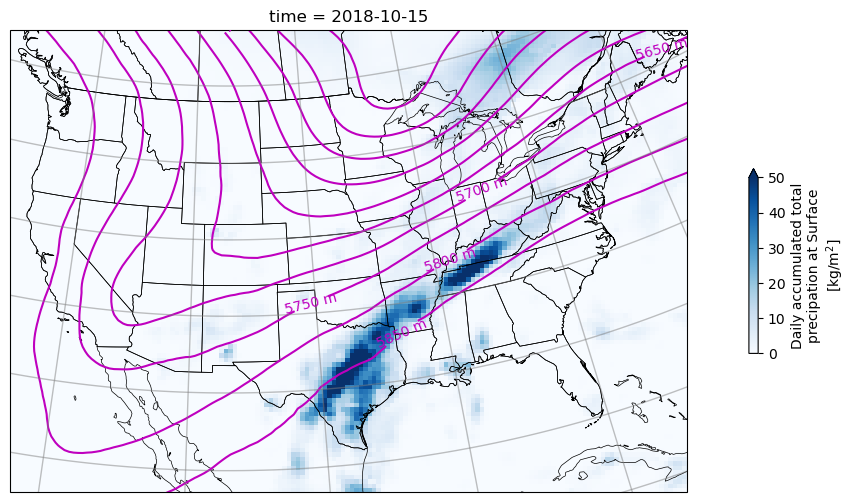

In [188]:
height_500 = ds_hgt['hgt'].sel(time='2018-10-15', level=500)
precipitation_day = ds_apcp['apcp'].sel(time='2018-10-15')

cen_lon = ds_apcp.Lambert_Conformal.attrs.get('longitude_of_central_meridian')
cen_lat = ds_apcp.Lambert_Conformal.attrs.get('latitude_of_projection_origin')
false_easting = ds_apcp.Lambert_Conformal.attrs.get('false_easting')
false_northing = ds_apcp.Lambert_Conformal.attrs.get('false_northing')
projection = ccrs.LambertConformal(
    central_longitude=cen_lon,
    central_latitude=cen_lat,
    false_easting=false_easting,
    false_northing=false_northing
)

plt.figure(figsize=(16,6))
ax = plt.axes(projection=projection)
ax.set_extent([-122, -75, 23, 50], crs=ccrs.PlateCarree())
ax.add_feature(cp.feature.STATES, edgecolor='k', linewidth=0.5)
ax.add_feature(cp.feature.BORDERS, edgecolor='k', linewidth=0.5)
ax.add_feature(cp.feature.COASTLINE, edgecolor='k', linewidth=0.5)

levels=np.arange(5000,5900,50)
contour = height_500.plot.contour(ax=ax,
                                  x='x', y='y',
                                  transform=projection,
                                  levels=levels,
                                  colors='m')
ax.clabel(contour, inline=True, fmt='%d m', colors='m')

precipitation_day.plot(ax=ax, 
                       x='x', y='y',
                       transform=projection,
                       cmap='Blues',vmax=50,
                       cbar_kwargs= {'shrink': 0.4,
                                     'label':'Daily accumulated total\nprecipation at Surface\n[kg/m$^2$]'}
                      )
ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='gray',alpha=0.5, linestyle='-')
plt.title('time = 2018-10-15')


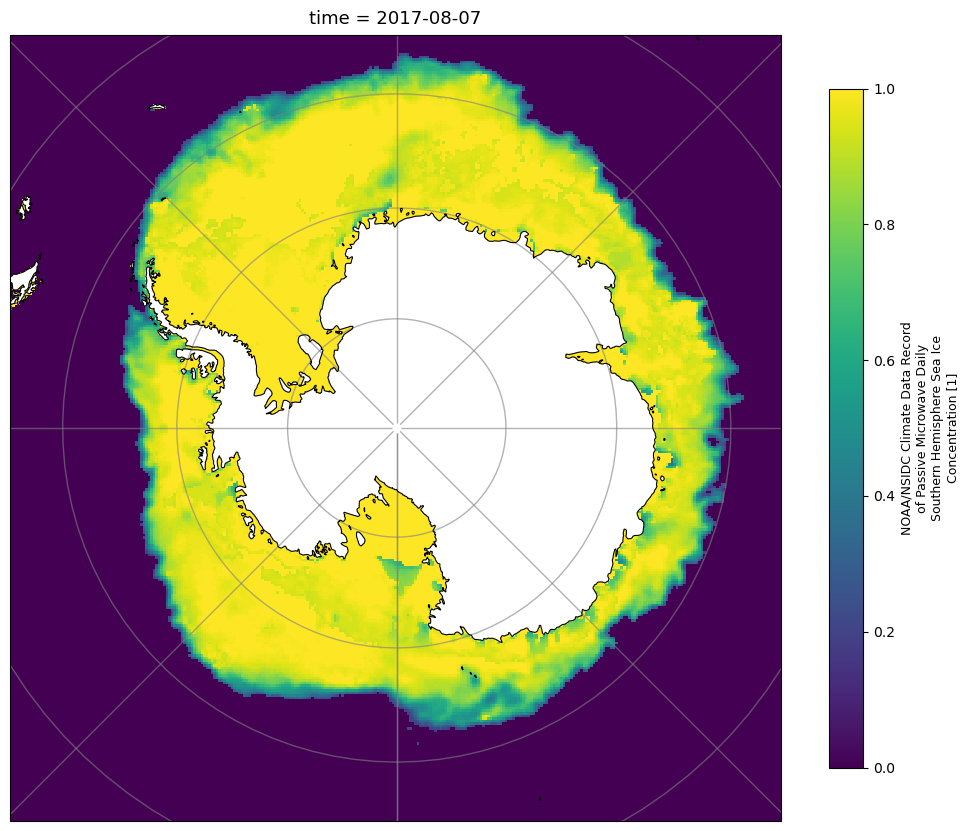

In [189]:
import pandas as pd
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')


ice_proj = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-70
)


sic = ds_ice["seaice_conc_cdr"].isel(time=0)

sic_data = sic.values.astype(float)
sic_data[sic_data < 0] = np.nan

xgrid = ds_ice["xgrid"].values
ygrid = ds_ice["ygrid"].values


fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ice_proj}
)

ax.set_facecolor("black")

pcm = ax.pcolormesh(
    xgrid, ygrid, sic_data,
    cmap="viridis",
    transform=ice_proj,
    vmin=0, vmax=1,
    zorder=2
)

cbar = plt.colorbar(pcm, ax=ax, orientation="vertical",
                    shrink=0.7, pad=0.05)
cbar.set_label("NOAA/NSIDC Climate Data Record\nof Passive Microwave Daily\nSouthern Hemisphere Sea Ice\nConcentration [1]",
               fontsize=9)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

ax.add_feature(cfeature.LAND, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

gl = ax.gridlines(
    linewidth=1.0, color="grey", alpha=0.6,
    linestyle="-", zorder=10,
    xlocs=range(-180, 181, 45),  
    ylocs=range(-90, -40, 10) )


ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

ax.set_title("time = 2017-08-07", fontsize=13, pad=8)

plt.tight_layout()
plt.savefig("antarctic_seaice.png", dpi=150, bbox_inches="tight")


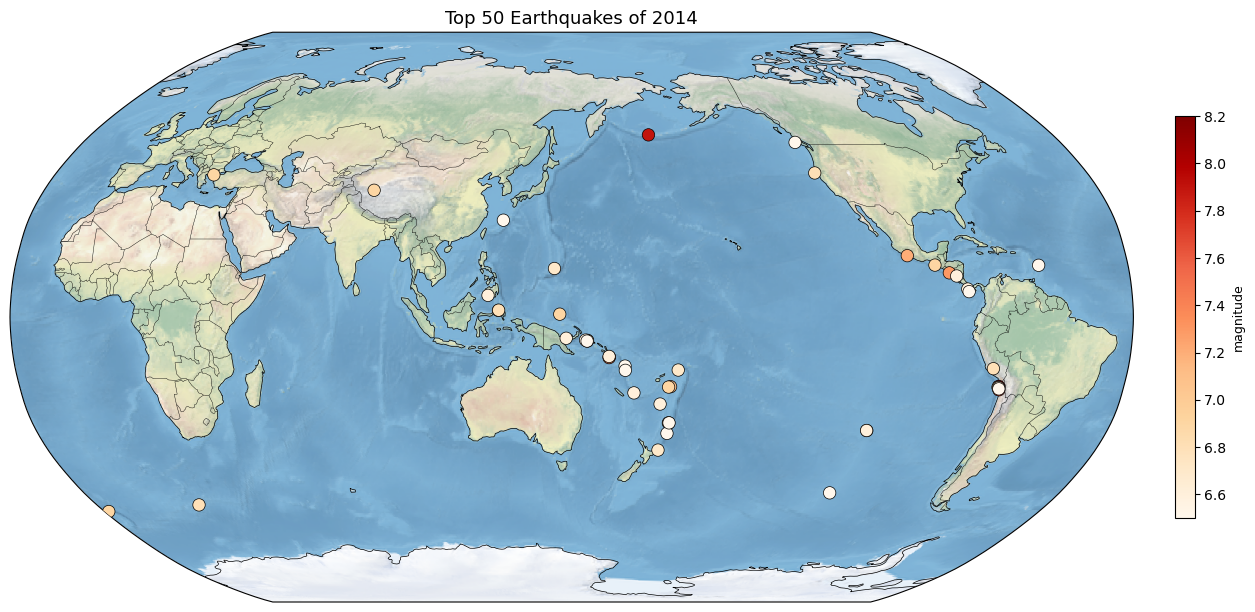

In [190]:
earth_url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(earth_url)


top50 = df.nlargest(50, "mag")


fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=150)}
)
ax.set_global()


ax.stock_img()

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)


sc = ax.scatter(
    top50["longitude"], top50["latitude"],
    c=top50["mag"],
    cmap="OrRd",
    s=80,
    edgecolors="black",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)


cbar = plt.colorbar(sc, ax=ax, orientation="vertical",
                    shrink=0.6, pad=0.03)
cbar.set_label("magnitude", fontsize=9)

ax.set_title("Top 50 Earthquakes of 2014", fontsize=13)

plt.tight_layout()
plt.savefig("usgs_earthquakes.png", dpi=150, bbox_inches="tight")
